## Proyecto 2: Entrenamiento del Modelo

El dataset utilizado para este proyecto se puede encontrar en el siguiente enlace: https://www.kaggle.com/datasets/karagwaanntreasure/plant-disease-detection?select=Dataset

In [ ]:
#imports

import random
from pathlib import Path
from collections import Counter, defaultdict
import pandas as pd
from tqdm import tqdm
import time

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

In [53]:
#Usar dataset local
model_dir = Path.cwd()
if model_dir.name != "Modelo" and (model_dir / "Modelo").exists():
    model_dir = model_dir / "Modelo"

subset_root = model_dir / "data" / "tomato_subset"

print("Dataset local:", subset_root)
print("Existe:", subset_root.exists())

Dataset local: c:\Users\diego\OneDrive\Documentos\GitHub\Escuela\ICProyecto2\Modelo\data\tomato_subset
Existe: True


In [54]:
#Clases objetivo
TOMATO_CLASSES = [
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy"
]

CLASS_ALIASES = {
    "Tomato_Spider_mites_Two_spotted_spider_mite": "tomato_spider_mide",
}

def class_alias(class_name):
    return CLASS_ALIASES.get(class_name, class_name)

def graph_label(class_name):
    label = class_alias(class_name)
    changed = True

    while changed:
        changed = False
        for prefix in ("Tomato__", "Tomato_", "tomato_"):
            if label.startswith(prefix):
                label = label[len(prefix):]
                changed = True

    return label

## EDA

### Size

In [ ]:
#Dataset size
class_counts = {}
total_images = 0

for class_name in TOMATO_CLASSES:
    count = len(list((subset_root / class_name).glob("*.jpg")))
    class_counts[class_name] = count
    total_images += count

print("Total images in tomato subset:", total_images)
print("\nImages per class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

Total images in tomato subset: 16010

Images per class:
Tomato_Bacterial_spot: 2127
Tomato_Early_blight: 1000
Tomato_Late_blight: 1908
Tomato_Leaf_Mold: 952
Tomato_Septoria_leaf_spot: 1771
Tomato_Spider_mites_Two_spotted_spider_mite: 1676
Tomato__Target_Spot: 1404
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208
Tomato__Tomato_mosaic_virus: 373
Tomato_healthy: 1591


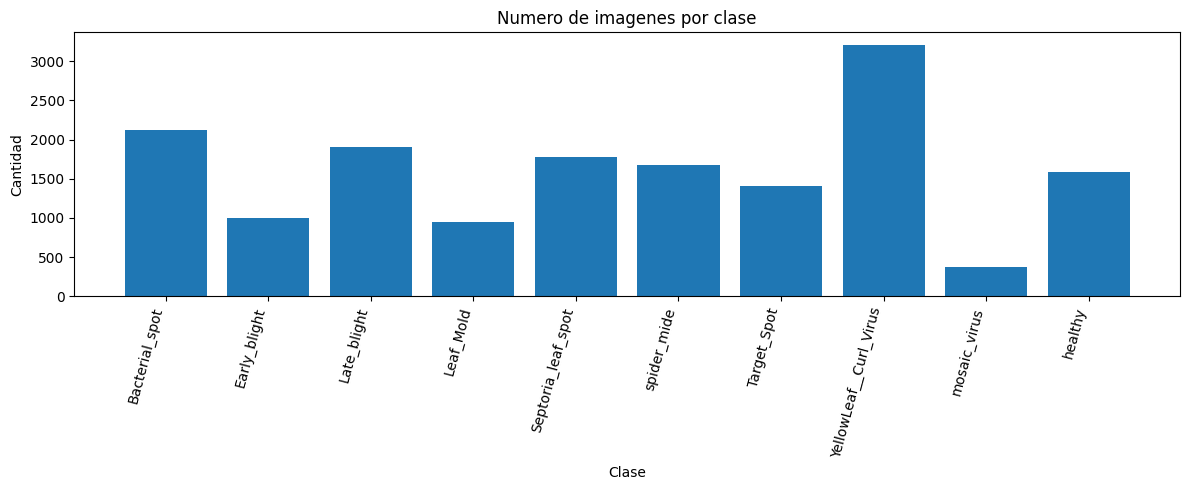

In [56]:
#Distribucion de clases
plt.figure(figsize=(12, 5))
graph_labels = [graph_label(class_name) for class_name in class_counts.keys()]

plt.bar(graph_labels, class_counts.values())
plt.xticks(rotation=75, ha="right")
plt.title("Numero de imagenes por clase")
plt.ylabel("Cantidad")
plt.xlabel("Clase")
plt.tight_layout()
plt.show()

### Image dimensions

In [62]:
all_image_paths = []
for class_name in TOMATO_CLASSES:
    all_image_paths.extend(list((subset_root / class_name).glob("*.jpg")))

sample_paths = random.sample(all_image_paths, min(300, len(all_image_paths)))

sizes = []
for img_path in sample_paths:
    with Image.open(img_path) as img:
        sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print("Width min/max:", min(widths), max(widths))
print("Height min/max:", min(heights), max(heights))
print("Example dimensions:", sizes[:10])

Width min/max: 256 256
Height min/max: 256 256
Example dimensions: [(256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256), (256, 256)]


### Examples of each class

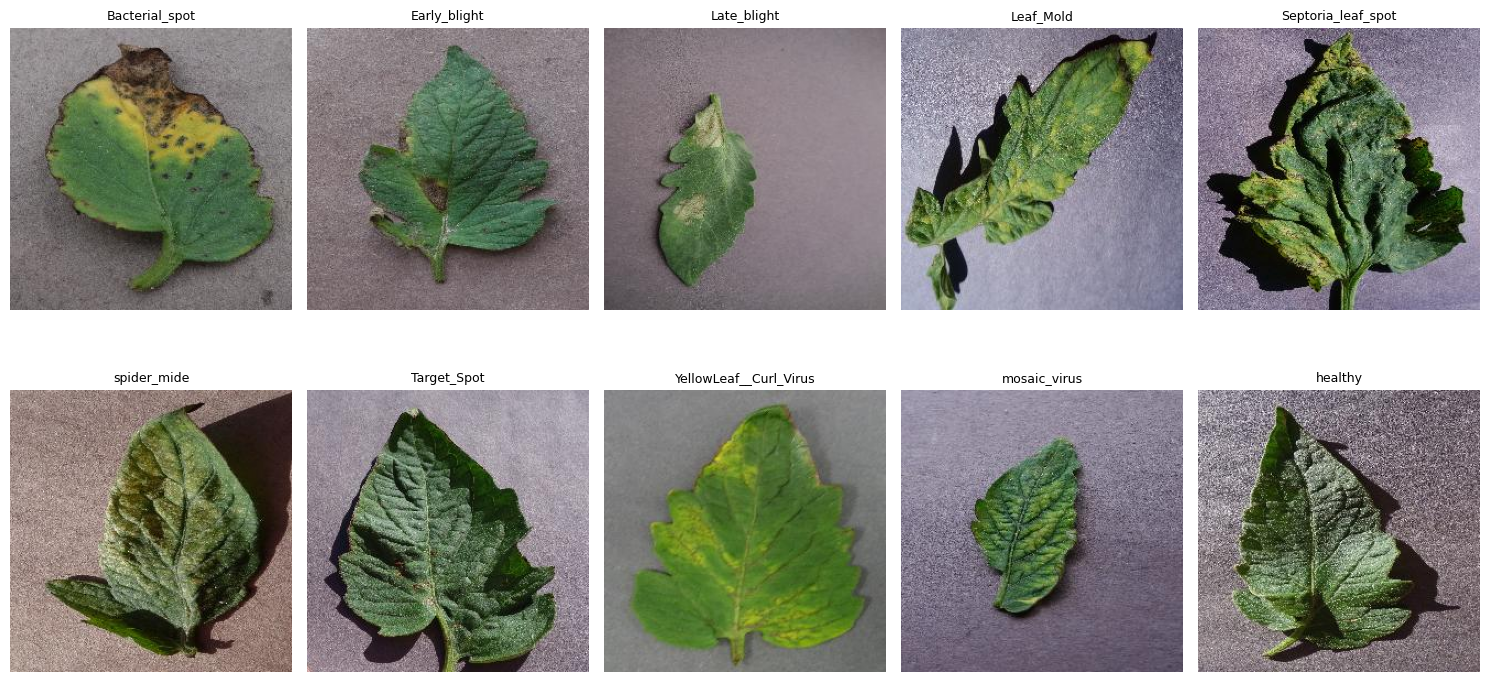

In [75]:
#Una imagen por clase
plt.figure(figsize=(15, 8))

for i, class_name in enumerate(TOMATO_CLASSES, 1):
    class_dir = subset_root / class_name
    image_paths = [
        img_path for img_path in class_dir.iterdir()
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}
    ]

    if not image_paths:
        continue

    img_path = random.choice(image_paths)
    img = Image.open(img_path).convert("RGB")

    plt.subplot(2, 5, i)
    plt.imshow(img)
    plt.title(graph_label(class_name), fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Conclusion de EDA

El EDA mostró que el subconjunto de tomate es adecuado para un problema de clasificación multiclase, ya que cuenta con 16,010 imágenes repartidas en 10 clases. También se observó que todas las imágenes tienen un tamaño uniforme de 256×256 píxeles, lo que facilita su uso en modelos de deep learning. No obstante, existe cierto desbalance entre clases, pues algunas tienen muchas más imágenes que otras. En general, el dataset se ve consistente y suficiente para entrenar modelos de redes neuronales convolucionales.



## Preprocesamiento

In [ ]:
# Definición de transformaciones para entrenamiento (data augmentation)  validación y entrenamiento (estandarización)

IMG_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomRotation(20),  # hojas pueden rotar
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Cargar dataset completo

full_dataset = datasets.ImageFolder(
    root=subset_root,
    transform=val_test_transforms  # temporal
)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Clases:", class_names)
print("Número de clases:", num_classes)

In [ ]:
# Dividir dataset en entrenamiento, validación y prueba

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset,
    [train_size, val_size, test_size]
)

print(len(train_dataset), len(val_dataset), len(test_dataset))

In [ ]:
# Aplicar trasformaciones y generar data loaders

class TransformedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        x = self.transform(x)
        return x, y


train_dataset = TransformedDataset(train_dataset, train_transforms)
val_dataset = TransformedDataset(val_dataset, val_test_transforms)
test_dataset = TransformedDataset(test_dataset, val_test_transforms)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Generar pesos de clases para que la función de pérdida de más peso a errores en clases menos comunes

targets = [label for _, label in full_dataset.samples]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(targets),
    y=targets
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

## Entrenamiento de los Modelos

In [ ]:
# Función para obtener accuracy por batch

def get_batch_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

# Función de entrenamiento con data augmentation y retorno del registro de pérdida y accuracy para curvas de aprendizaje

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, aug_transforms=None):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        start_time = time.time()

        # Entrenamiento
        model.train()
        running_loss = 0.0
        running_acc = 0.0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for X_batch, y_batch in loop:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            # Data augmentation
            if aug_transforms is not None:
                X_batch = aug_transforms(X_batch)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Obtener accuracy
            acc = get_batch_accuracy(outputs, y_batch)

            running_loss += loss.item()
            running_acc += acc

            loop.set_postfix(loss=loss.item(), acc=acc)

        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = running_acc / len(train_loader)

        # Evaluación en validación
        model.eval()
        val_loss = 0.0
        val_acc = 0.0

        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val = X_val.to(device)
                y_val = y_val.to(device)

                outputs = model(X_val)
                loss = criterion(outputs, y_val)

                acc = get_batch_accuracy(outputs, y_val)

                val_loss += loss.item()
                val_acc += acc

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_acc = val_acc / len(val_loader)

        # Guardar historial
        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        end_time = time.time()

        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
        print(f"Val   Loss: {epoch_val_loss:.4f} | Val   Acc: {epoch_val_acc:.4f}")
        print(f"Time: {end_time - start_time:.2f}s")

    return history

In [ ]:
# Definición de función de pérdida

loss_fn = nn.CrossEntropyLoss(weight=class_weights)

# Definición del modelo 1

model_1 = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(32 * 56 * 56, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
).to(device)

#Definición del modelo 2

model_2 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(128 * 28 * 28, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
).to(device)

#Definición del modelo 3

model_3 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3, padding=1),
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(64, 128, 3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(128 * 28 * 28, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
).to(device)

# Definir optimizadores y épocas
optimizer_1 = torch.optim.Adam(model_1.parameters(), lr=0.001)
optimizer_2 = torch.optim.Adam(model_2.parameters(), lr=0.0005)
optimizer_3 = torch.optim.Adam(model_3.parameters(), lr=0.0001)

num_epochs = 10

# Mostrar número de parámetros
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

param_data = {
    "Modelo": ["Modelo 1", "Modelo 2", "Modelo 3"],
    "Parámetros": [
        count_parameters(model_1),
        count_parameters(model_2),
        count_parameters(model_3)
    ]
}

df_params = pd.DataFrame(param_data)
df_params

In [ ]:
# Entrenamiento del modelo 1

history_1 = train_model(model_1, train_loader, val_loader, loss_fn, optimizer_1, num_epochs)

In [ ]:
# Entrenamiento del modelo 2

history_2 = train_model(model_2, train_loader, val_loader, loss_fn, optimizer_2, num_epochs)


In [ ]:
# Entrenamiento del modelo 3

history_3 = train_model(model_3, train_loader, val_loader, loss_fn, optimizer_3, num_epochs)

In [ ]:
# Mostrar curvas de aprendizaje

def plot_learning_curves(history, title):

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,5))

    # Pérdida
    plt.subplot(1,2,1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_1, "Modelo 1")
plot_learning_curves(history_2, "Modelo 2")
plot_learning_curves(history_3, "Modelo 3")

### Elección del Mejor Modelo

## Evaluación del Modelo

## Serialización del Modelo